In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

In [2]:
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [3]:
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the electrocadriogram data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

In [4]:
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

In [5]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

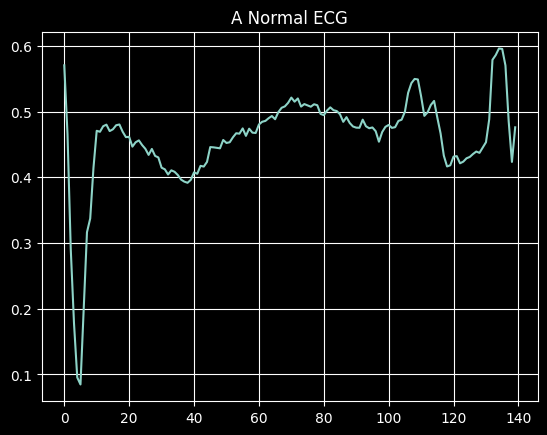

In [6]:
plt.grid()
plt.plot(np.arange(140), normal_train_data[0])
plt.title("A Normal ECG")
plt.show()

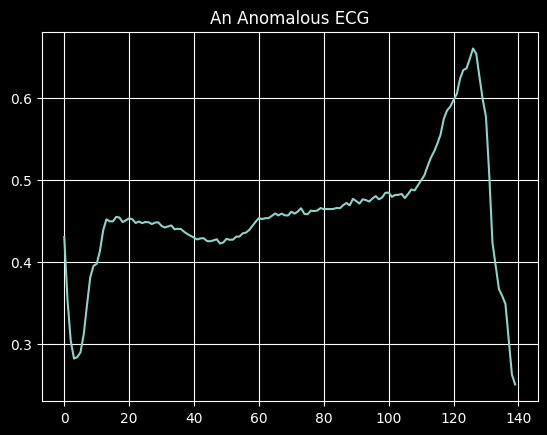

In [7]:
plt.grid()
plt.plot(np.arange(140), anomalous_train_data[0])
plt.title("An Anomalous ECG")
plt.show()

In [8]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, Model

In [9]:

# -------------------------------------------------
# 1) Create a validation split from NORMAL training data
# -------------------------------------------------
n = len(normal_train_data)
idx = tf.random.shuffle(tf.range(n), seed=42)
x = tf.gather(normal_train_data, idx)

split = int(0.8 * n)
x_train = x[:split]
x_val = x[split:]

In [10]:


INPUT_DIM = int(normal_train_data.shape[1])

class AnomalyDetector(tf.keras.Model):
    def __init__(self, input_dim, h1, h2, latent_dim, activation="relu"):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            layers.Dense(h1, activation=activation),
            layers.Dense(h2, activation=activation),
            layers.Dense(latent_dim, activation=activation),
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(h2, activation=activation),
            layers.Dense(h1, activation=activation),
            layers.Dense(input_dim, activation="sigmoid"),
        ])
    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [11]:

# -------------------------------------------------
# 3) Define the stochastic search space
# -------------------------------------------------
def build_autoencoder(hp):
    model = AnomalyDetector(
        input_dim=INPUT_DIM,
        h1=hp.Choice("h1", [64, 128, 140, 256]),
        h2=hp.Choice("h2", [16, 32, 64]),
        latent_dim=hp.Choice("latent_dim", [4, 8, 16]),
        activation=hp.Choice("activation", ["relu", "elu", "tanh"]),
    )

    _ = model(tf.zeros((1, INPUT_DIM), dtype=tf.float32))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
        ),
        loss="mae",
    )
    return model

In [12]:

# -------------------------------------------------
# 4) Random search
# -------------------------------------------------
tuner = kt.RandomSearch(
    hypermodel=build_autoencoder,
    objective="val_loss",
    max_trials=30,
    overwrite=False,   # set False if you want to reload your existing search project
    directory="tuning",
    project_name="ae_random_search",
)

best_hps = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

print(best_hps.values)

Reloading Tuner from tuning\ae_random_search\tuner0.json

{'h1': 140, 'h2': 60, 'latent_dim': 8, 'activation': 'elu', 'dropout': 0.1, 'learning_rate': 0.0016228511966086888}


C:\pitProj\aai-env\.aivenv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
best_hps = tuner.get_best_hyperparameters(1)[0]
best_model = build_autoencoder(best_hps)   # already built because of dummy call



# Load weights from the best trial
best_trial = tuner.oracle.get_best_trials(1)[0]
checkpoint_path = tuner._get_checkpoint_fname(best_trial.trial_id)
best_model.load_weights(checkpoint_path)

print("Best hyperparameters:", best_hps.values)
print("Validation reconstruction MAE:", best_model.evaluate(x_val, x_val, verbose=0))

# Only now touch the test set
print("Test reconstruction MAE:", best_model.evaluate(test_data, test_data, verbose=0))


Best hyperparameters: {'h1': 140, 'h2': 60, 'latent_dim': 8, 'activation': 'elu', 'dropout': 0.1, 'learning_rate': 0.0016228511966086888}


C:\pitProj\aai-env\.aivenv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Validation reconstruction MAE: 0.01626959629356861
Test reconstruction MAE: 0.028426697477698326


Best hyperparameters: {'h1': 140, 'h2': 60, 'latent_dim': 8, 'activation': 'elu', 'dropout': 0.1, 'learning_rate': 0.0016228511966086888}

In [14]:
history = best_model.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    epochs=50,
    batch_size=512,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    shuffle=True
)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0357 - val_loss: 0.0292
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0256 - val_loss: 0.0218
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0214 - val_loss: 0.0216
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0205 - val_loss: 0.0207
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0198 - val_loss: 0.0198
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0189 - val_loss: 0.0183
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0179 - val_loss: 0.0175
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0172 - val_loss: 0.0169
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0168 - val_loss: 0.0166
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0167 - val_loss: 0.0171
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0165 - val_loss: 0.0160
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0160 - val_loss: 0.0161
E

In [15]:
autoencoder = best_model

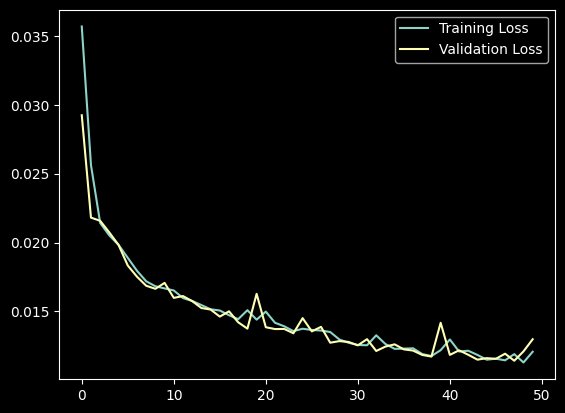

In [16]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

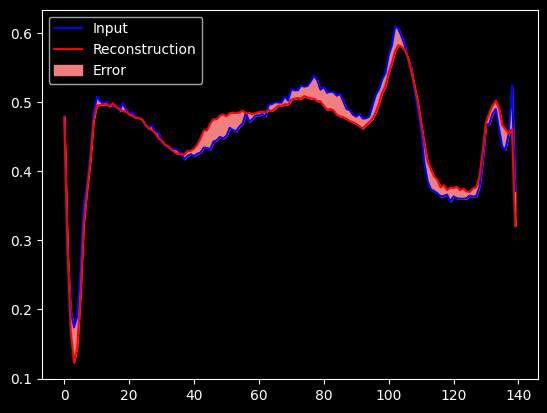

In [17]:
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(normal_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(140), decoded_data[0], normal_test_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()

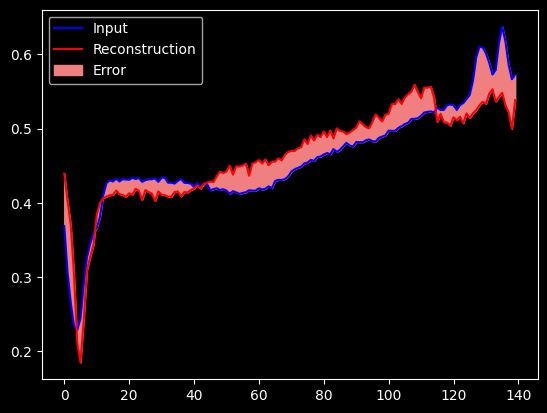

In [18]:
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(anomalous_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(140), decoded_data[0], anomalous_test_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


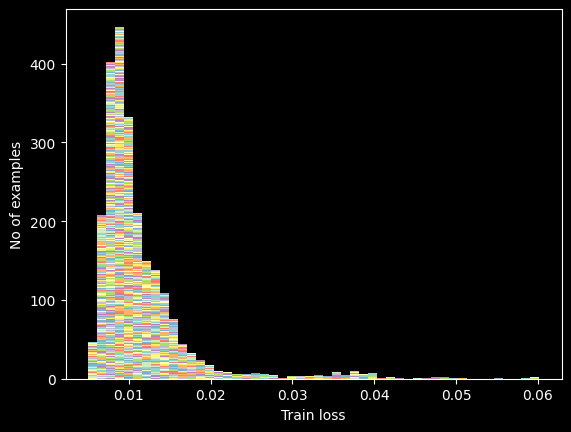

In [19]:
reconstructions = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

plt.hist(train_loss[None,:], histtype="barstacked", bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

In [20]:
threshold = np.mean(train_loss) + np.std(train_loss)
print("Threshold: ", threshold)


Threshold:  0.017485732


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


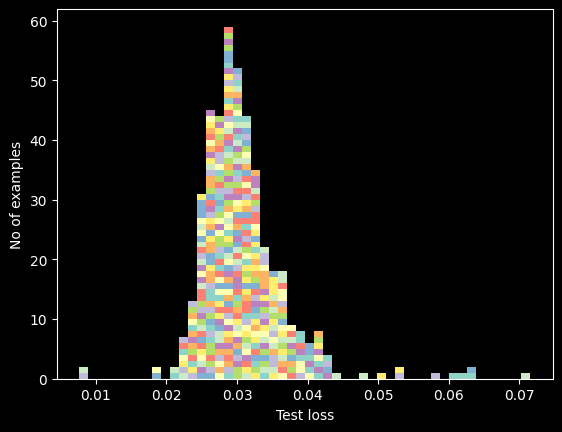

In [21]:
reconstructions = autoencoder.predict(anomalous_test_data)
test_loss = tf.keras.losses.mae(reconstructions, anomalous_test_data)

plt.hist(test_loss[None, :],histtype="barstacked", bins=50)
plt.xlabel("Test loss")
plt.ylabel("No of examples")
plt.show()

In [22]:
def predict(model, data, threshold):
    reconstructions = model(data)
    loss = tf.keras.losses.mae(reconstructions, data)
    return tf.math.less(loss, threshold)

def print_stats(predictions, labels):
    print("Accuracy = {}".format(accuracy_score(labels, predictions)))
    print("Precision = {}".format(precision_score(labels, predictions)))
    print("Recall = {}".format(recall_score(labels, predictions)))

In [23]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.957
Precision = 0.9961612284069098
Recall = 0.9267857142857143
